# Import Libraries

In [1]:
import sys
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data and path configuration

In [3]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import RAW_DATA_DIR, INTERIM_DATA_DIR

import pandas as pd

Interim_data_path = INTERIM_DATA_DIR / "diabetes_data_interim.csv"

# Load the CSV
file_path = RAW_DATA_DIR / "raw_diabetes_data.csv"
df = pd.read_csv(file_path)
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# Preprocessing

### removing Duplicates

In [4]:
initial_shape = df.shape
df = df.drop_duplicates()
duplicates_removed = initial_shape[0] - df.shape[0]
print(f"Duplicates removed: {duplicates_removed}")

Duplicates removed: 1635


### Identifying Outliers

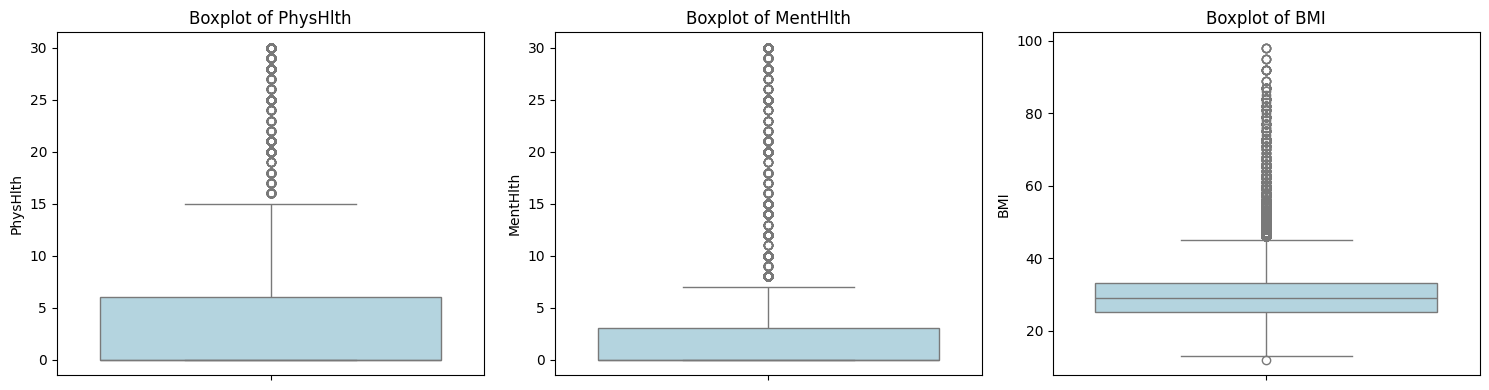

In [5]:
num_cols = ['PhysHlth', 'MentHlth','BMI']

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

- Most columns in the dataset are either binary or represent bucketed categorical values. For such variables, outlier detection is not meaningful and has been skipped.

- The only truly continuous numerical column is BMI. While it does contain statistical outliers, we have chosen to retain them, as they may carry important signals relevant to identifying individuals with diabetes and maybe clinically significant.

In [6]:
Interim_data_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(Interim_data_path, index=False)
print(f"Interim-Cleaned data saved Successfully")

Interim-Cleaned data saved Successfully
